In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
years = range(1997, 2026)
for year in years:
    exec(f"data_{year} = pd.read_csv(f'data/output/data-{year}.csv')")

#merged
dfs = []
for year in years:
    df = pd.read_csv(f'data/output/data-{year}.csv')
    dfs.append(df)

# Concatenate into one DataFrame
data = pd.concat(dfs, ignore_index=True)

In [4]:
filtered = data[(data["year"] >= 2009) & (data["year"] <= 2019)]

In [5]:
filtered.head()

,provider_number,fy_start,fy_end,date_processed,date_created,beds,tot_charges,tot_discounts,tot_operating_exp,ip_charges,...,secondary_mcare_payment,street,city,state,zip,county,hvbp_payment,hrrp_payment,year,source
64238,10001,2008-10-01,2009-09-30,2010-11-03,2010-10-25,370.0,980776069.0,744725360.0,244567428.0,91187217.0,...,557218.0,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301-,HOUSTON,NaN,NaN,2009,unique reports
64239,10005,2008-10-01,2009-09-30,2010-05-25,2010-05-21,114.0,184944919.0,120670619.0,68806697.0,10411901.0,...,11957.0,2505 U.S. HIGHWAY 431,BOAZ,AL,35957-,MARSHALL,NaN,NaN,2009,unique reports
64240,10006,2008-07-01,2009-06-30,2013-02-19,2012-10-16,369.0,655289596.0,522494168.0,138055299.0,40479386.0,...,252644.0,205 MARENGO,FLORENCE,AL,35631-,LAUDERDALE,NaN,NaN,2009,unique reports
64241,10007,2008-10-01,2009-09-30,2013-05-30,2013-05-21,78.0,49087280.0,33509498.0,16809041.0,3278460.0,...,NaN,702 MAIN STREET,OPP,AL,36462-,COVINGTON,NaN,NaN,2009,unique reports
64242,10008,2009-01-01,2009-12-31,2010-06-11,2010-06-10,29.0,25498474.0,15851037.0,9739449.0,2116408.0,...,NaN,101 HOSPITAL CIRCLE,LUVERNE,AL,36049-,CRENSHAW,NaN,NaN,2009,unique reports


### Question 1

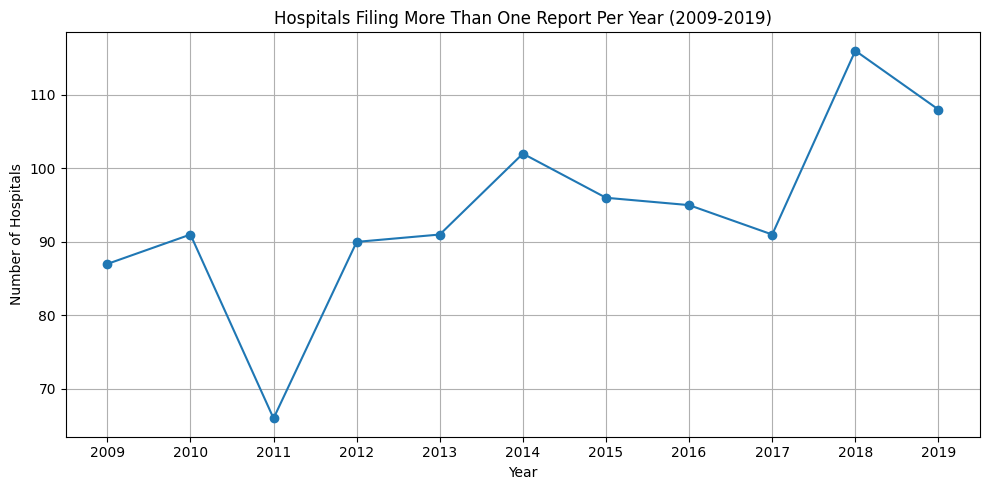

In [6]:
multi = filtered[(filtered['source'] != 'unique reports') & 
              (filtered['year'] >= 2009) & 
              (filtered['year'] <= 2019)]

result = multi.groupby('year')['provider_number'].nunique().reset_index()
result.columns = ['year', 'num_hospitals']

plt.figure(figsize=(10, 5))
plt.plot(result['year'], result['num_hospitals'], marker='o')
plt.title('Hospitals Filing More Than One Report Per Year (2009-2019)')
plt.xlabel('Year')
plt.ylabel('Number of Hospitals')
plt.xticks(result['year'])
plt.grid(True)
plt.tight_layout()
plt.show()

### Question 2

In [7]:
# Restrict to 2009–2019
data_q2 = data[(data["year"] >= 2009) & (data["year"] <= 2019)].copy()

# Standardize column names
data_q2.columns = data_q2.columns.str.lower().str.strip()

# Find provider ID column
provider_col = None
for col in ["prvdr_num", "provider_number", "provider_num", "prov_num", "ccn"]:
    if col in data_q2.columns:
        provider_col = col
        break

if provider_col is None:
    raise ValueError("No provider ID column found.")

# Try to find a date column to decide which duplicate report to keep
date_col = None
for col in ["fy_end", "fy_bgn", "proc_dt", "rpt_rec_num", "report_date"]:
    if col in data_q2.columns:
        date_col = col
        break

# Drop missing provider IDs
data_q2 = data_q2.dropna(subset=[provider_col]).copy()
data_q2[provider_col] = data_q2[provider_col].astype(str).str.strip()

# If a usable date column exists, sort and keep the last report in each hospital-year
if date_col is not None:
    data_q2[date_col] = pd.to_datetime(data_q2[date_col], errors="coerce")
    data_q2 = data_q2.sort_values([provider_col, "year", date_col])
    data_q2_clean = data_q2.drop_duplicates(subset=[provider_col, "year"], keep="last")
else:
    # Otherwise just keep the first report for each hospital-year
    data_q2_clean = data_q2.drop_duplicates(subset=[provider_col, "year"])

# Count unique hospital IDs after removing/combining multiple reports
num_unique_hospitals = data_q2_clean[provider_col].nunique()

print("Unique hospital IDs after removing/combining multiple reports (2009–2019):")
print(num_unique_hospitals)

Unique hospital IDs after removing/combining multiple reports (2009–2019):
6897


### Question 3

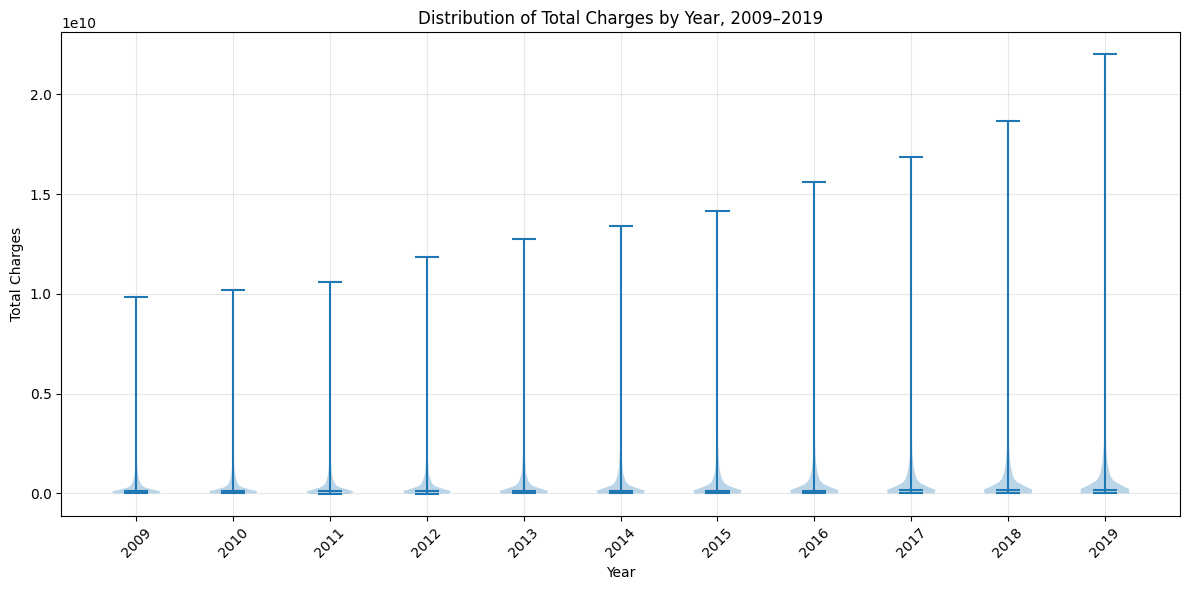

In [8]:
# Restrict to 2009–2019
data_q3 = data[(data["year"] >= 2009) & (data["year"] <= 2019)].copy()

# Standardize column names
data_q3.columns = data_q3.columns.str.lower().str.strip()

# Keep only non-missing total charges
data_q3 = data_q3.dropna(subset=["tot_charges"]).copy()

# Optional: make sure tot_charges is numeric
data_q3["tot_charges"] = pd.to_numeric(data_q3["tot_charges"], errors="coerce")
data_q3 = data_q3.dropna(subset=["tot_charges"])

# Build data for violin plot
plot_data = []
year_labels = []

for year in range(2009, 2020):
    charges = data_q3.loc[data_q3["year"] == year, "tot_charges"]
    plot_data.append(charges)
    year_labels.append(str(year))

# Create violin plot
plt.figure(figsize=(12, 6))
plt.violinplot(plot_data, showmeans=False, showmedians=True)
plt.xticks(range(1, len(year_labels) + 1), year_labels, rotation=45)
plt.xlabel("Year")
plt.ylabel("Total Charges")
plt.title("Distribution of Total Charges by Year, 2009–2019")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 4

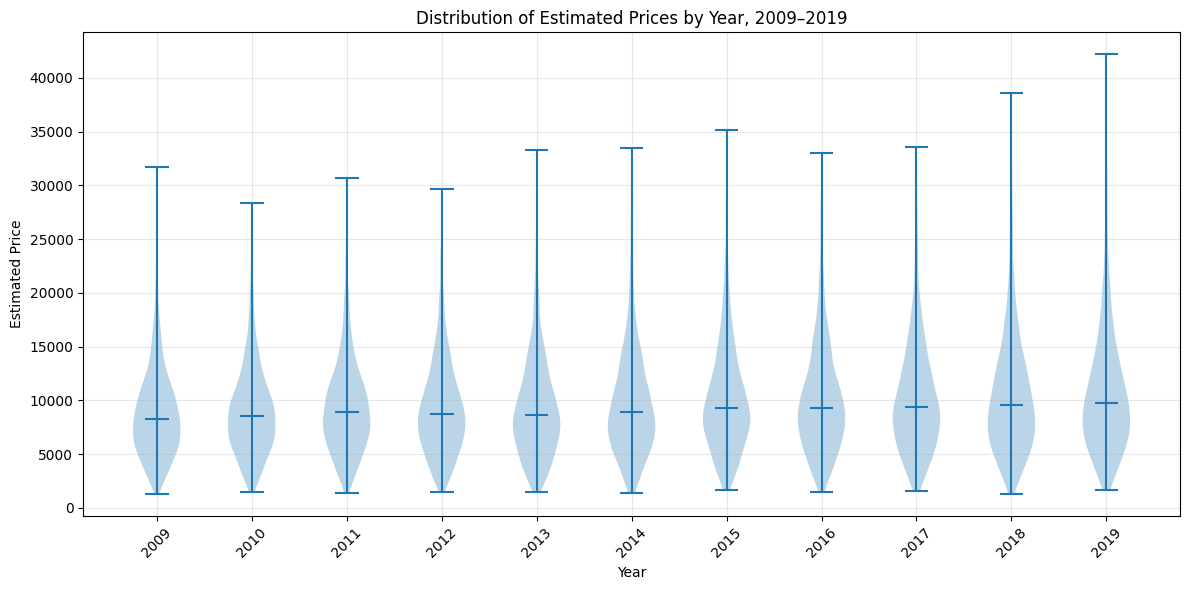

In [9]:
# Restrict to 2009–2019
data_q4 = data[(data["year"] >= 2009) & (data["year"] <= 2019)].copy()

# Standardize column names
data_q4.columns = data_q4.columns.str.lower().str.strip()

# Columns needed for estimated price
needed_cols = [
    "tot_discounts",
    "tot_charges",
    "ip_charges",
    "icu_charges",
    "ancillary_charges",
    "tot_mcare_payment",
    "tot_discharges",
    "mcare_discharges"
]

# Keep only rows with all needed columns present
data_q4 = data_q4.dropna(subset=needed_cols).copy()

# Convert needed columns to numeric
for col in needed_cols:
    data_q4[col] = pd.to_numeric(data_q4[col], errors="coerce")

data_q4 = data_q4.dropna(subset=needed_cols).copy()

# Compute estimated price
data_q4["discount_factor"] = 1 - data_q4["tot_discounts"] / data_q4["tot_charges"]
data_q4["price_num"] = (
    (data_q4["ip_charges"] + data_q4["icu_charges"] + data_q4["ancillary_charges"])
    * data_q4["discount_factor"]
    - data_q4["tot_mcare_payment"]
)
data_q4["price_denom"] = data_q4["tot_discharges"] - data_q4["mcare_discharges"]
data_q4["price"] = data_q4["price_num"] / data_q4["price_denom"]

# Remove invalid values
data_q4 = data_q4.replace([np.inf, -np.inf], np.nan)
data_q4 = data_q4.dropna(subset=["price"]).copy()

# Remove negative prices
data_q4 = data_q4[data_q4["price"] > 0].copy()

# Remove extreme outliers within each year using 1st and 99th percentiles
filtered_list = []
for year in range(2009, 2020):
    temp = data_q4[data_q4["year"] == year].copy()
    if len(temp) > 0:
        lower = temp["price"].quantile(0.01)
        upper = temp["price"].quantile(0.99)
        temp = temp[(temp["price"] >= lower) & (temp["price"] <= upper)]
        filtered_list.append(temp)

data_q4_clean = pd.concat(filtered_list, ignore_index=True)

# Build data for violin plot
plot_data = []
year_labels = []

for year in range(2009, 2020):
    prices = data_q4_clean.loc[data_q4_clean["year"] == year, "price"]
    plot_data.append(prices)
    year_labels.append(str(year))

# Plot
plt.figure(figsize=(12, 6))
plt.violinplot(plot_data, showmeans=False, showmedians=True)
plt.xticks(range(1, len(year_labels) + 1), year_labels, rotation=45)
plt.xlabel("Year")
plt.ylabel("Estimated Price")
plt.title("Distribution of Estimated Prices by Year, 2009–2019")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 5

   year  penalized  share_percent
0  2012   0.200577      20.057720
1  2013   0.526258      52.625821
2  2014   0.551661      55.166052
3  2015   0.677241      67.724087
4  2016   0.700222      70.022206
5  2017   0.691099      69.109948
6  2018   0.716586      71.658555
7  2019   0.722769      72.276853


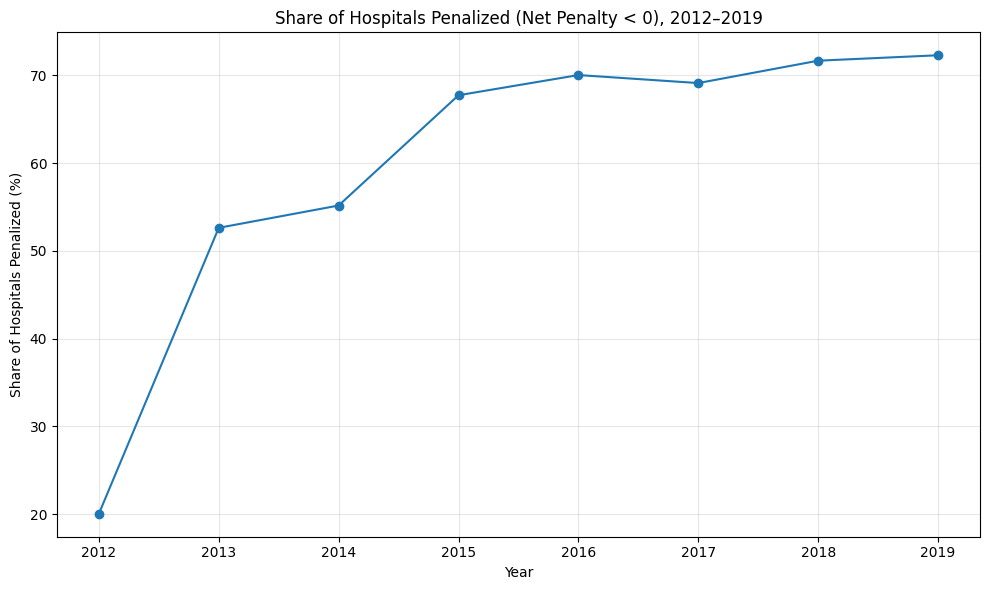

In [18]:
import matplotlib.pyplot as plt

# Restrict to 2012–2019
data_q5 = filtered[(filtered["year"] >= 2012) & (filtered["year"] <= 2019)].copy()

# Create net penalty
data_q5["net_penalty"] = (1 - data_q5["hrrp_payment"]) + (1 - data_q5["hvbp_payment"])

# Penalized indicator: net_penalty < 0
data_q5["penalized"] = (data_q5["net_penalty"] < 0).astype(int)

# Share penalized by year
share_penalized = data_q5.groupby("year")["penalized"].mean().reset_index()

# Convert to percent
share_penalized["share_percent"] = share_penalized["penalized"] * 100

print(share_penalized)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(share_penalized["year"], share_penalized["share_percent"], marker="o")

plt.xlabel("Year")
plt.ylabel("Share of Hospitals Penalized (%)")
plt.title("Share of Hospitals Penalized (Net Penalty < 0), 2012–2019")

plt.xticks(share_penalized["year"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 6

In [22]:
from statsmodels.iolib.summary2 import summary_col

def calc_price(df):
    df = df.copy()
    df['discount_factor'] = 1 - df['tot_discounts'] / df['tot_charges']
    df['price_num'] = (df['ip_charges'] + df['icu_charges'] + df['ancillary_charges']) * df['discount_factor'] - df['tot_mcare_payment']
    df['price_denom'] = df['tot_discharges'] - df['mcare_discharges']
    df['price'] = df['price_num'] / df['price_denom']
    return df

price_2011 = calc_price(filtered[filtered['year'] == 2011])[['provider_number', 'price']].rename(columns={'price': 'price_2011'})
price_2014 = calc_price(filtered[filtered['year'] == 2014])[['provider_number', 'price']].rename(columns={'price': 'price_2014'})
price_change = price_2011.merge(price_2014, on='provider_number')
price_change['price_change'] = price_change['price_2014'] - price_change['price_2011']

pen_2012 = filtered[filtered['year'] == 2012][['provider_number', 'hrrp_payment', 'hvbp_payment']].copy()
pen_2012['hrrp_payment'] = pen_2012['hrrp_payment'].fillna(0)
pen_2012['hvbp_payment'] = pen_2012['hvbp_payment'].fillna(0)
pen_2012['net_penalty'] = pen_2012['hrrp_payment'] + pen_2012['hvbp_payment']

# Pre-2012 
pre = filtered[(filtered['year'] >= 2009) & (filtered['year'] <= 2011)]
pre_avg = pre.groupby('provider_number').agg(
    avg_mcare_discharges=('mcare_discharges', 'mean'),
    avg_beds=('beds', 'mean'),
    avg_mcaid_discharges=('mcaid_discharges', 'mean')
).reset_index()

# merge
df_iv = price_change.merge(pen_2012[['provider_number', 'net_penalty']], on='provider_number')
df_iv = df_iv.merge(pre_avg, on='provider_number')

# clean
df_iv = df_iv[df_iv['price_2011'] > 0]
df_iv = df_iv[df_iv['price_2014'] > 0]
df_iv = df_iv[df_iv['price_change'].between(df_iv['price_change'].quantile(0.01), df_iv['price_change'].quantile(0.99))]

# reg
ols1 = smf.ols('price_change ~ net_penalty', data=df_iv).fit()
ols2 = smf.ols('price_change ~ net_penalty + avg_beds', data=df_iv).fit()
ols3 = smf.ols('price_change ~ net_penalty + avg_beds + avg_mcaid_discharges', data=df_iv).fit()

table = summary_col(
    [ols1, ols2, ols3],
    stars=True,
    model_names=['Baseline', 'Baseline + Beds', 'Baseline + Beds + Medicaid'],
    info_dict={'N': lambda x: f"{int(x.nobs):,}", 'R²': lambda x: f"{x.rsquared:.3f}"}
)

print(table)



                       Baseline  Baseline + Beds Baseline + Beds + Medicaid
---------------------------------------------------------------------------
Intercept            259.7588*** 241.5526***     115.4846**                
                     (46.3418)   (46.8373)       (57.9008)                 
net_penalty          0.0019      0.0019          0.0017                    
                     (0.0013)    (0.0013)        (0.0013)                  
avg_beds                         0.0736**        0.0659**                  
                                 (0.0289)        (0.0289)                  
avg_mcaid_discharges                             0.0791***                 
                                                 (0.0216)                  
R-squared            0.0009      0.0036          0.0091                    
R-squared Adj.       0.0005      0.0027          0.0079                    
N                    2,417       2,417           2,409                     
R²         

### Question 7

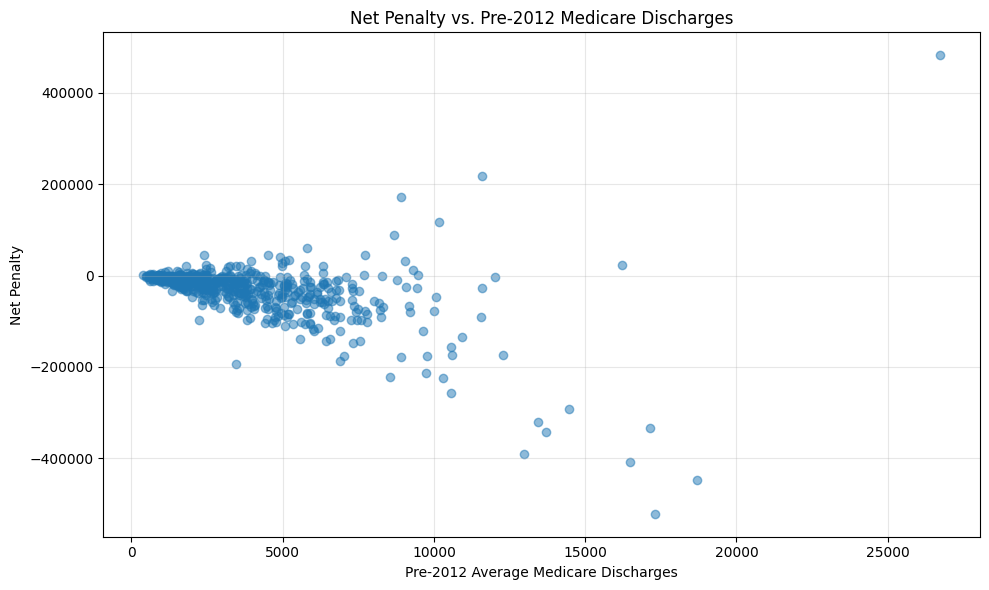

In [13]:
import matplotlib.pyplot as plt

# Scatterplot of net penalty vs pre-2012 Medicare discharges
plt.figure(figsize=(10, 6))
plt.scatter(df_iv['avg_mcare_discharges'], df_iv['net_penalty'], alpha=0.5)

plt.xlabel('Pre-2012 Average Medicare Discharges')
plt.ylabel('Net Penalty')
plt.title('Net Penalty vs. Pre-2012 Medicare Discharges')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 8

In [14]:
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

# ----------------------------
# FIRST STAGE
# net_penalty ~ instrument
# ----------------------------
fs1 = smf.ols('net_penalty ~ avg_mcare_discharges', data=df_iv).fit()
fs2 = smf.ols('net_penalty ~ avg_mcare_discharges + avg_beds', data=df_iv).fit()
fs3 = smf.ols('net_penalty ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges', data=df_iv).fit()

fs_table = summary_col(
    [fs1, fs2, fs3],
    stars=True,
    model_names=['FS Baseline', 'FS + Beds', 'FS + Beds + Medicaid'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print("FIRST STAGE RESULTS")
print(fs_table)


# ----------------------------
# REDUCED FORM
# d_price ~ instrument
# ----------------------------
rf1 = smf.ols('d_price ~ avg_mcare_discharges', data=df_iv).fit()
rf2 = smf.ols('d_price ~ avg_mcare_discharges + avg_beds', data=df_iv).fit()
rf3 = smf.ols('d_price ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges', data=df_iv).fit()

rf_table = summary_col(
    [rf1, rf2, rf3],
    stars=True,
    model_names=['RF Baseline', 'RF + Beds', 'RF + Beds + Medicaid'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print("\nREDUCED FORM RESULTS")
print(rf_table)

FIRST STAGE RESULTS

                     FS Baseline  FS + Beds  FS + Beds + Medicaid
-----------------------------------------------------------------
Intercept            3912.1618   3837.7234   2998.7921           
                     (3955.8389) (3960.4214) (4011.3074)         
avg_mcare_discharges -9.4730***  -9.4937***  -10.0029***         
                     (0.8101)    (0.8114)    (0.9021)            
avg_beds                         0.4278      0.4204              
                                 (0.7615)    (0.7611)            
avg_mcaid_discharges                         1.8645              
                                             (1.4468)            
R-squared            0.1927      0.1931      0.1955              
R-squared Adj.       0.1913      0.1903      0.1912              
N                    575         575         575                 
R2                   0.193       0.193       0.195               
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<

### Question 9

In [15]:
iv_coef1 = rf1.params['avg_mcare_discharges'] / fs1.params['avg_mcare_discharges']
iv_coef2 = rf2.params['avg_mcare_discharges'] / fs2.params['avg_mcare_discharges']
iv_coef3 = rf3.params['avg_mcare_discharges'] / fs3.params['avg_mcare_discharges']

print("IV Estimates of net penalty effect on price change:")
print(f"  Baseline:                  {iv_coef1:.4f}")
print(f"  Baseline + Beds:           {iv_coef2:.4f}")
print(f"  Baseline + Beds + Medicaid:{iv_coef3:.4f}")

IV Estimates of net penalty effect on price change:
  Baseline:                  -0.0026
  Baseline + Beds:           -0.0022
  Baseline + Beds + Medicaid:0.0008


In [16]:
iv_results = pd.DataFrame({
    'Specification': ['Baseline', 'Baseline + Beds', 'Baseline + Beds + Medicaid'],
    'IV Estimate': [iv_coef1, iv_coef2, iv_coef3]
})

print(iv_results)

                Specification  IV Estimate
0                    Baseline    -0.002550
1             Baseline + Beds    -0.002166
2  Baseline + Beds + Medicaid     0.000772


In [17]:
### Question 10: Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?